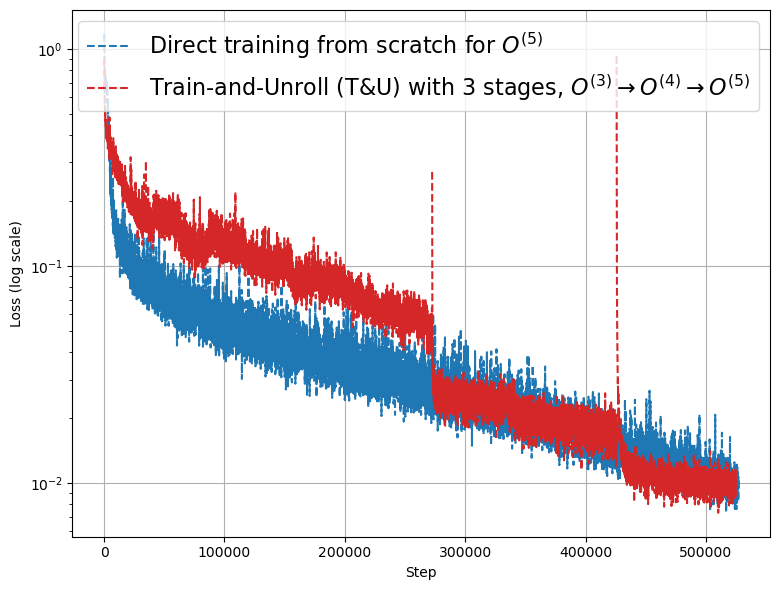

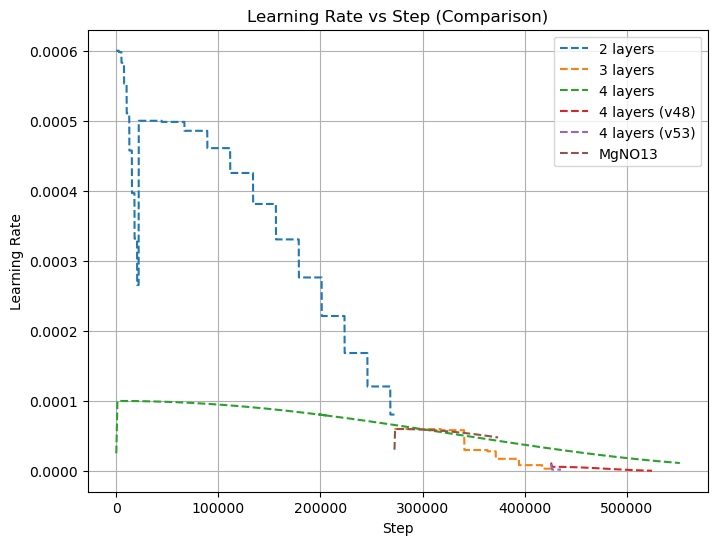

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

# ——— Load all CSVs into a dict with clean keys ———
paths = {
    "baseline":    "/ibex/ai/home/liux0t/AI4S-cupv2/lightning_logs/version_61_11/metrics.csv",  # your original first file
    "v69_12_1":    "/ibex/ai/home/liux0t/AI4S-cupv2/lightning_logs/version_69_12.1/metrics.csv",
    "v32":         "/ibex/ai/home/liux0t/AI4S-cupv2/logs/lightning_logs/version_32/metrics.csv",
    "v86_13_1":    "/ibex/ai/home/liux0t/AI4S-cupv2/lightning_logs/version_86_13.1/metrics.csv",
    "v88_13_1":    "/ibex/ai/home/liux0t/AI4S-cupv2/lightning_logs/version_88_13.1/metrics.csv",
    "v91_13_1a":   "/ibex/ai/home/liux0t/AI4S-cupv2/lightning_logs/version_91_13.1/metrics.csv",
    "v91_13_1b":   "/ibex/ai/home/liux0t/AI4S-cupv2/lightning_logs/version_91_13.1/metrics_2.csv",
    "v93_14_1":    "/ibex/ai/home/liux0t/AI4S-cupv2/lightning_logs/version_93_14.1/metrics.csv",
    "v48":         "/ibex/ai/home/liux0t/AI4S-cupv2/logs/lightning_logs/version_48/metrics.csv",
    "v53":         "/ibex/ai/home/liux0t/AI4S-cupv2/logs/lightning_logs/version_53/metrics.csv",
    "v42_mgno5":   "/ibex/ai/home/liux0t/AI4S-cupv2/logs/lightning_logs/version_42/metrics.csv",
    "v32_mgno13":  "/ibex/ai/home/liux0t/AI4S-cupv2/logs/lightning_logs/version_32/metrics.csv",
    "v54":         "/ibex/ai/home/liux0t/AI4S-cupv2/logs/lightning_logs/version_54/metrics.csv",
    "v55":         "/ibex/ai/home/liux0t/AI4S-cupv2/logs/lightning_logs/version_55/metrics.csv",
    "v57":         "/ibex/ai/home/liux0t/AI4S-cupv2/logs/lightning_logs/version_57/metrics.csv",
    "v58":         "/ibex/ai/home/liux0t/AI4S-cupv2/logs/lightning_logs/version_58/metrics.csv",
}

# Load and prune to the three columns we care about
metrics = {}
for k, p in paths.items():
    df = pd.read_csv(p)
    metrics[k] = df[['step', 'loss_step', 'learning_rate_step']].dropna()

# ——— 1) ADJUST STEP VALUES TO MAKE SEQUENCES CONTINUOUS ———
# exactly in the order from your original snippet:
metrics["v69_12_1"]['step']   += metrics["baseline"]['step'].max()
metrics["v32"]['step']        += metrics["v69_12_1"]['step'].max()
metrics["v86_13_1"]['step']   += metrics["v69_12_1"]['step'].max()
metrics["v88_13_1"]['step']   += metrics["v86_13_1"]['step'].max()
metrics["v91_13_1a"]['step']  += metrics["v88_13_1"]['step'].max()
metrics["v91_13_1b"]['step']  += metrics["v88_13_1"]['step'].max()
metrics["v93_14_1"]['step']   += metrics["v91_13_1a"]['step'].max()
metrics["v48"]['step']        += metrics["v91_13_1a"]['step'].max()
metrics["v53"]['step']        += metrics["v91_13_1a"]['step'].max()
metrics["v32_mgno13"]['step'] += metrics["v69_12_1"]['step'].max()
metrics["v57"]['step']        += metrics["v55"]['step'].max()
# (all others keep their original zero‐based steps)

# ——— 2) COMBINE SOME LOSS CURVES FOR GROUPED PLOTTING ———
two_layer   = pd.concat([metrics["baseline"], metrics["v69_12_1"]])
three_layer = pd.concat([metrics["v86_13_1"], metrics["v88_13_1"], metrics["v91_13_1a"]])
four_layer  = pd.concat([metrics["v42_mgno5"], metrics["v54"], metrics["v55"], metrics["v58"]])

# ——— PLOT #1: loss_step ———
plt.figure(figsize=(8, 6))
plt.plot(four_layer['step'][:-500],  four_layer['loss_step'][:-500],  label='Direct training from scratch for $O^{(5)}$', linestyle='--')
plt.plot(two_layer['step'],   two_layer['loss_step'],   label=r'Train-and-Unroll (T&U) with 3 stages, $O^{(3)} \rightarrow O^{(4)} \rightarrow O^{(5)}$', color='#d62728', linestyle='--')
plt.plot(three_layer['step'], three_layer['loss_step'],  color='#d62728', linestyle='--') #label='Train-and-Unroll (T&U) phase 2 (l=4)',
plt.plot(metrics["v48"]['step'],       metrics["v48"]['loss_step'],  color='#d62728', linestyle='--') #label = 'Train-and-Unroll (T&U) phase 3 (l=5)',


# plt.plot(metrics["v53"]['step'],       metrics["v53"]['loss_step'],       label='4 layers (v53)', linestyle='--')
# plt.plot(metrics["v32_mgno13"]['step'],metrics["v32_mgno13"]['loss_step'],label='MgNO13',        linestyle='--')
plt.yscale('log')
plt.xlabel('Step')
plt.ylabel('Loss (log scale)')
# plt.title('Training Strategy Comparison: Train-and-Unroll vs. Direct Training', fontsize=14, pad=20)
# use large legend font size
plt.legend(fontsize=16, loc='upper right')
plt.grid(True)
# quality of the plot, set the dpi
plt.savefig('training_strategy_comparison.png', dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()

# ——— PLOT #2: learning_rate_step ———
plt.figure(figsize=(8, 6))
plt.plot(two_layer['step'],   two_layer['learning_rate_step'],   label='2 layers', linestyle='--')
plt.plot(three_layer['step'], three_layer['learning_rate_step'], label='3 layers', linestyle='--')
plt.plot(four_layer['step'],  four_layer['learning_rate_step'],  label='4 layers', linestyle='--')
plt.plot(metrics["v48"]['step'],       metrics["v48"]['learning_rate_step'],       label='4 layers (v48)', linestyle='--')
plt.plot(metrics["v53"]['step'],       metrics["v53"]['learning_rate_step'],       label='4 layers (v53)', linestyle='--')
plt.plot(metrics["v32_mgno13"]['step'],metrics["v32_mgno13"]['learning_rate_step'],label='MgNO13',            linestyle='--')
plt.xlabel('Step')
plt.ylabel('Learning Rate')
plt.title('Learning Rate vs Step (Comparison)')
plt.legend()
plt.grid(True)
plt.show()


/tmp/ipykernel_634725/206357718.py:89: RuntimeWarning: invalid value encountered in log10
  y_text_pos = 10**((np.log10(y_min) + np.log10(y_max)) / 2.2)
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


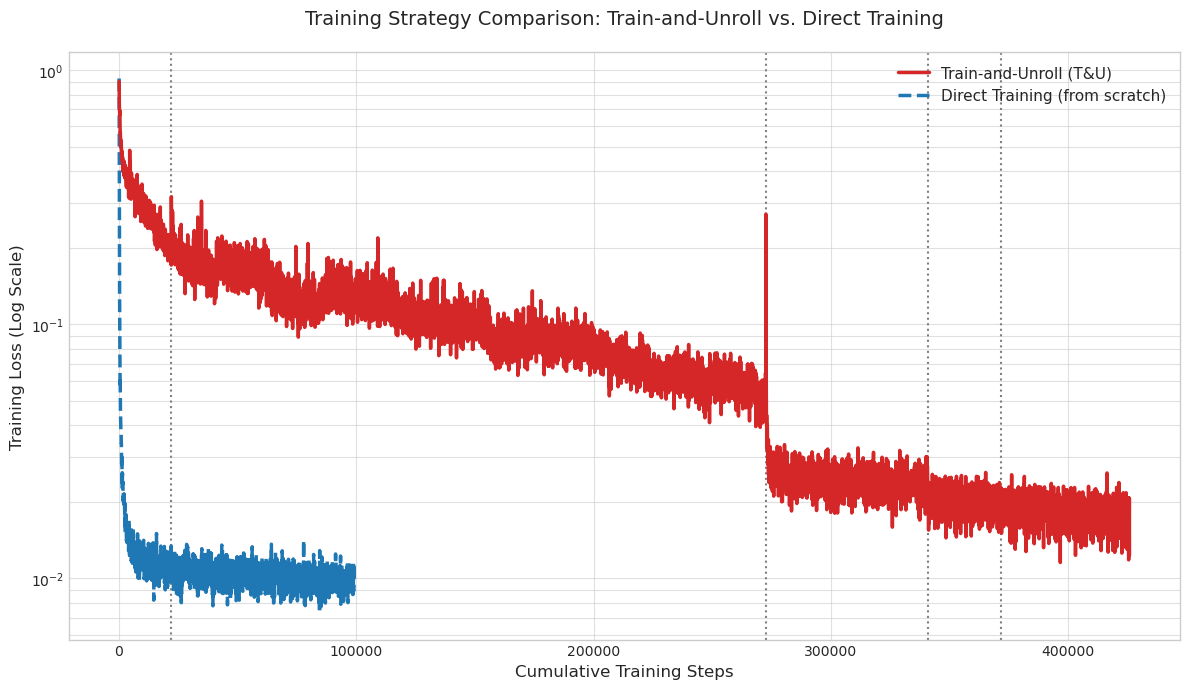

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.style as style
import numpy as np

# --- 1. Load Data & Adjust Steps (from your working script) ---
# NOTE: Using placeholder paths. The user must use their actual paths for this to run.
paths = {
    "baseline":    "/ibex/ai/home/liux0t/AI4S-cupv2/lightning_logs/version_61_11/metrics.csv",  # your original first file
    "v69_12_1":    "/ibex/ai/home/liux0t/AI4S-cupv2/lightning_logs/version_69_12.1/metrics.csv",
    "v32":         "/ibex/ai/home/liux0t/AI4S-cupv2/logs/lightning_logs/version_32/metrics.csv",
    "v86_13_1":    "/ibex/ai/home/liux0t/AI4S-cupv2/lightning_logs/version_86_13.1/metrics.csv",
    "v88_13_1":    "/ibex/ai/home/liux0t/AI4S-cupv2/lightning_logs/version_88_13.1/metrics.csv",
    "v91_13_1a":   "/ibex/ai/home/liux0t/AI4S-cupv2/lightning_logs/version_91_13.1/metrics.csv",
    "v91_13_1b":   "/ibex/ai/home/liux0t/AI4S-cupv2/lightning_logs/version_91_13.1/metrics_2.csv",
    "v93_14_1":    "/ibex/ai/home/liux0t/AI4S-cupv2/lightning_logs/version_93_14.1/metrics.csv",
    "v48":         "/ibex/ai/home/liux0t/AI4S-cupv2/logs/lightning_logs/version_48/metrics.csv",
    "v53":         "/ibex/ai/home/liux0t/AI4S-cupv2/logs/lightning_logs/version_53/metrics.csv",
    "v42_mgno5":   "/ibex/ai/home/liux0t/AI4S-cupv2/logs/lightning_logs/version_42/metrics.csv",
    "v32_mgno13":  "/ibex/ai/home/liux0t/AI4S-cupv2/logs/lightning_logs/version_32/metrics.csv",
    "v54":         "/ibex/ai/home/liux0t/AI4S-cupv2/logs/lightning_logs/version_54/metrics.csv",
    "v55":         "/ibex/ai/home/liux0t/AI4S-cupv2/logs/lightning_logs/version_55/metrics.csv",
    "v57":         "/ibex/ai/home/liux0t/AI4S-cupv2/logs/lightning_logs/version_57/metrics.csv",
    "v58":         "/ibex/ai/home/liux0t/AI4S-cupv2/logs/lightning_logs/version_58/metrics.csv",
}

metrics = {}
for k, p in paths.items():
    try:
        df = pd.read_csv(p)
        # We only need 'step' and 'loss_step' for this plot.
        metrics[k] = df[['step', 'loss_step']].dropna()
    except FileNotFoundError:
        print(f"Warning: Could not find file for '{k}' at path '{p}'. Skipping.")
        metrics[k] = pd.DataFrame({'step': [], 'loss_step': []})

# --- 2. Define Training Strategies and Correctly Prepare Data ---

# The baseline is 'v48', which should start from step 0.
# We create a copy of it *before* any modifications are made.
baseline_df = metrics.get('v48', pd.DataFrame()).copy()

# The user's original script for adjusting steps is now applied.
# This prepares the T&U sequence data correctly.
if all(k in metrics for k in ["baseline", "v69_12_1", "v86_13_1", "v88_13_1", "v91_13_1a"]):
    metrics["v69_12_1"]['step']   += metrics["baseline"]['step'].max()
    metrics["v86_13_1"]['step']   += metrics["v69_12_1"]['step'].max()
    metrics["v88_13_1"]['step']   += metrics["v86_13_1"]['step'].max()
    metrics["v91_13_1a"]['step']  += metrics["v88_13_1"]['step'].max()
    # Note: Other adjustments from the original script are not needed for this specific plot.

# --- 3. Create a Single Continuous DataFrame for the T&U plot ---

# Define the sequence of keys for the Train-and-Unroll method
t_and_u_keys = ["baseline", "v69_12_1", "v86_13_1", "v88_13_1", "v91_13_1a"]
t_and_u_stage_labels = ["n=2", "Depth → 3", "Depth → 4", "Continue n=4", "Continue n=4"]

# Get the dataframes for the T&U sequence from the modified 'metrics' dict
t_and_u_stages = [metrics[k] for k in t_and_u_keys if k in metrics and not metrics[k].empty]

# Find the transition points (end of each stage)
transitions = []
if len(t_and_u_stages) > 1:
    for i in range(len(t_and_u_stages) - 1):
        transitions.append(t_and_u_stages[i]['step'].max())

# Combine all stages into a single dataframe for plotting
t_and_u_full_df = pd.concat(t_and_u_stages, ignore_index=True) if t_and_u_stages else pd.DataFrame()


# --- 4. Generate the Improved Plot ---
style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(12, 7))

# Plot the continuous Train-and-Unroll curve
if not t_and_u_full_df.empty:
    ax.plot(t_and_u_full_df['step'], t_and_u_full_df['loss_step'],
            label='Train-and-Unroll (T&U)', color='#d62728', linewidth=2.5, zorder=10)

# Plot the Direct Training baseline (using the preserved, unmodified copy)
if not baseline_df.empty:
    ax.plot(baseline_df['step'], baseline_df['loss_step'],
            label='Direct Training (from scratch)', color='#1f77b4', linestyle='--', linewidth=2.5, zorder=5)

# Add annotations for the T&U transitions
if not t_and_u_full_df.empty and transitions:
    y_min, y_max = ax.get_ylim()
    # Position text in the middle of log scale
    y_text_pos = 10**((np.log10(y_min) + np.log10(y_max)) / 2.2)

    for i, step in enumerate(transitions):
        ax.axvline(x=step, color='grey', linestyle=':', linewidth=1.5)
        # Add text label for the new stage
        ax.text(step + 10000, y_text_pos, t_and_u_stage_labels[i+1],
                rotation=90, verticalalignment='center', color='black', fontsize=11,
                bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=2))

# --- Final Touches for Clarity and Aesthetics ---
ax.set_yscale('log')
ax.set_xlabel('Cumulative Training Steps', fontsize=12)
ax.set_ylabel('Training Loss (Log Scale)', fontsize=12)
ax.set_title('Training Strategy Comparison: Train-and-Unroll vs. Direct Training', fontsize=14, pad=20)
ax.legend(fontsize=11, loc='upper right')
ax.grid(True, which="both", ls="-", alpha=0.6)
plt.tight_layout()
plt.show()

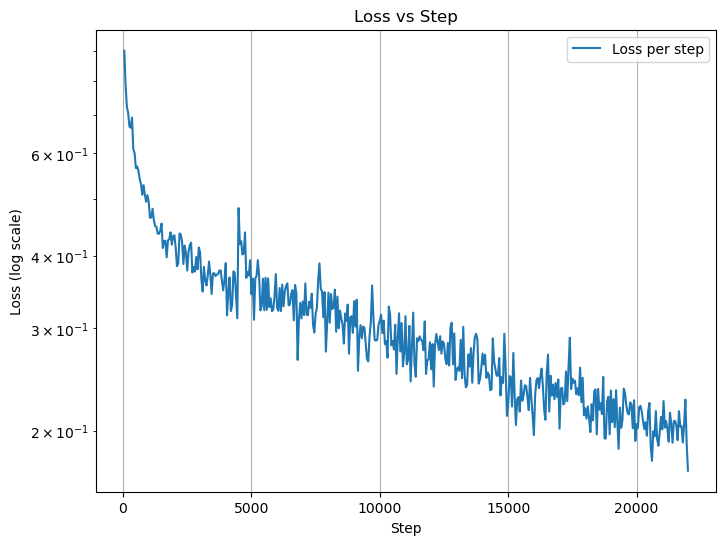

In [1]:
import pandas as pd

# Load the uploaded CSV file to check its contents
file_path = '/ibex/ai/home/liux0t/AI4S-cupv2/lightning_logs/version_61_11/metrics.csv'
metrics_df = pd.read_csv(file_path)

# Display the first few rows to understand its structure
metrics_df.head()
import matplotlib.pyplot as plt

# Extract the step and loss_step columns, filtering out NaN values
loss_data = metrics_df[['step', 'loss_step']].dropna()

# Plotting the loss record with only the y-axis in log scale
plt.figure(figsize=(8, 6))
plt.plot(loss_data['step'], loss_data['loss_step'], label='Loss per step')
plt.yscale('log')
plt.xlabel('Step')
plt.ylabel('Loss (log scale)')
plt.title('Loss vs Step')
plt.legend()
plt.grid(True)

# Display the plot
plt.show()


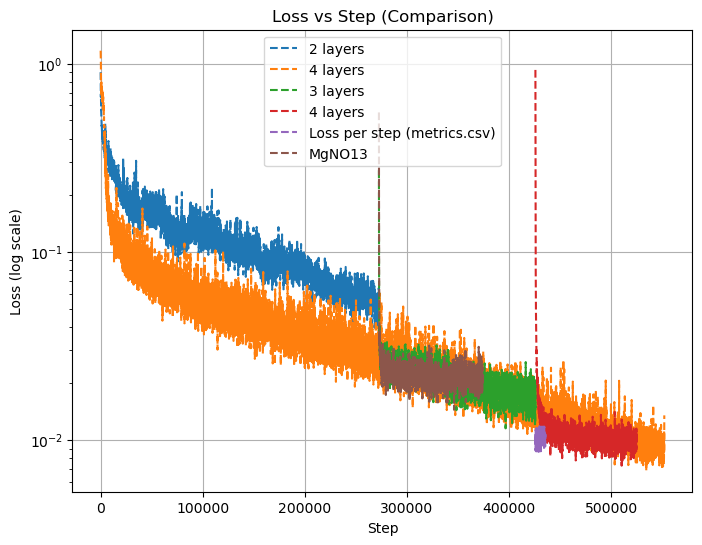

In [4]:
# Load the second uploaded CSV file to check its contents
file_path_2 = '/ibex/ai/home/liux0t/AI4S-cupv2/lightning_logs/version_69_12.1/metrics.csv'
metrics_df_2 = pd.read_csv(file_path_2)

file_path_3 = '/ibex/ai/home/liux0t/AI4S-cupv2/logs/lightning_logs/version_32/metrics.csv'
metrics_df_3 = pd.read_csv(file_path_3)

file_path_4 = '/ibex/ai/home/liux0t/AI4S-cupv2/lightning_logs/version_86_13.1/metrics.csv'
metrics_df_4 = pd.read_csv(file_path_4)

file_path_5 = '/ibex/ai/home/liux0t/AI4S-cupv2/lightning_logs/version_88_13.1/metrics.csv'
metrics_df_5 = pd.read_csv(file_path_5)

file_path_6 = '/ibex/ai/home/liux0t/AI4S-cupv2/lightning_logs/version_91_13.1/metrics.csv'
metrics_df_6 = pd.read_csv(file_path_6)

file_path_7 = '/ibex/ai/home/liux0t/AI4S-cupv2/lightning_logs/version_91_13.1/metrics_2.csv'
metrics_df_7 = pd.read_csv(file_path_7)

file_path_8 = '/ibex/ai/home/liux0t/AI4S-cupv2/lightning_logs/version_93_14.1/metrics.csv'
metrics_df_8 = pd.read_csv(file_path_8)

file_path_9 = '/ibex/ai/home/liux0t/AI4S-cupv2/logs/lightning_logs/version_48/metrics.csv'
metrics_df_9 = pd.read_csv(file_path_9)

file_path_10 = '/ibex/ai/home/liux0t/AI4S-cupv2/logs/lightning_logs/version_53/metrics.csv'
metrics_df_10 = pd.read_csv(file_path_10)

file_path_11 = '/ibex/ai/home/liux0t/AI4S-cupv2/logs/lightning_logs/version_42/metrics.csv' # MgNO5
metrics_df_11 = pd.read_csv(file_path_11)

file_path_12 = '/ibex/ai/home/liux0t/AI4S-cupv2/logs/lightning_logs/version_32/metrics.csv' # MgNO13  从MgNO_12重新训练
metrics_df_12 = pd.read_csv(file_path_12)

file_path_13 = '/ibex/ai/home/liux0t/AI4S-cupv2/logs/lightning_logs/version_54/metrics.csv' 
metrics_df_13 = pd.read_csv(file_path_13)

file_path_14 = '/ibex/ai/home/liux0t/AI4S-cupv2/logs/lightning_logs/version_55/metrics.csv'
metrics_df_14 = pd.read_csv(file_path_14)

file_path_15 = '/ibex/ai/home/liux0t/AI4S-cupv2/logs/lightning_logs/version_57/metrics.csv'
metrics_df_15 = pd.read_csv(file_path_15)

file_path_16 = '/ibex/ai/home/liux0t/AI4S-cupv2/logs/lightning_logs/version_58/metrics.csv'
metrics_df_16 = pd.read_csv(file_path_16)


# Display the first few rows to understand its structure
metrics_df_2.head()
# metrics_df_3.head()
# metrics_df_4.head()
# metrics_df_5.head()
# metrics_df_6.head()

# Extract the step and loss_step columns, filtering out NaN values from the second metrics file
loss_data_2 = metrics_df_2[['step', 'loss_step']].dropna()
loss_data_3 = metrics_df_3[['step', 'loss_step']].dropna()
loss_data_4 = metrics_df_4[['step', 'loss_step']].dropna()
loss_data_5 = metrics_df_5[['step', 'loss_step']].dropna()
loss_data_6 = metrics_df_6[['step', 'loss_step']].dropna()
loss_data_7 = metrics_df_7[['step', 'loss_step']].dropna()
loss_data_8 = metrics_df_8[['step', 'loss_step']].dropna()
loss_data_9 = metrics_df_9[['step', 'loss_step']].dropna()
loss_data_10 = metrics_df_10[['step', 'loss_step']].dropna()
loss_data_11 = metrics_df_11[['step', 'loss_step']].dropna()
loss_data_12 = metrics_df_12[['step', 'loss_step']].dropna()
loss_data_13 = metrics_df_13[['step', 'loss_step']].dropna()
loss_data_14 = metrics_df_14[['step', 'loss_step']].dropna()
loss_data_15 = metrics_df_15[['step', 'loss_step']].dropna()
loss_data_16 = metrics_df_16[['step', 'loss_step']].dropna()

loss_data_2['step'] += loss_data['step'].max()
loss_data_3['step'] += loss_data_2['step'].max()
loss_data_4['step'] += loss_data_2['step'].max()
loss_data_5['step'] += loss_data_4['step'].max()
loss_data_6['step'] += loss_data_5['step'].max()
loss_data_7['step'] += loss_data_5['step'].max()
loss_data_8['step'] += loss_data_6['step'].max()
loss_data_9['step'] += loss_data_6['step'].max()
loss_data_10['step'] += loss_data_6['step'].max()
loss_data_12['step'] += loss_data_2['step'].max()
loss_data_15['step'] += loss_data_14['step'].max()

combined_loss_data_all = pd.concat([loss_data, loss_data_2, ])
loss_data_4 = pd.concat([loss_data_4, loss_data_5, loss_data_6, ]) # loss_data_7

loss_data_11 = pd.concat([loss_data_11, loss_data_13, loss_data_14,  loss_data_16, ])

# Plotting both loss records in the same plot with y-axis in log scale
plt.figure(figsize=(8, 6))
# plt.plot(loss_data['step'], loss_data['loss_step'], label='Loss per step (metrics5.csv)')
# plt.plot(loss_data['step'], loss_data['loss_step'], label='Loss per step (metrics.csv)', linestyle='--')
plt.plot(combined_loss_data_all['step'], combined_loss_data_all ['loss_step'], label='2 layers', linestyle='--')
plt.plot(loss_data_11['step'], loss_data_11['loss_step'], label='4 layers', linestyle='--')

plt.plot(loss_data_4['step'], loss_data_4['loss_step'], label='3 layers', linestyle='--')
# plt.plot(loss_data_6['step'], loss_data_6['loss_step'], label='Loss per step (metrics.csv)', linestyle='--')
plt.plot(loss_data_9['step'], loss_data_9['loss_step'], label='4 layers', linestyle='--')
plt.plot(loss_data_10['step'], loss_data_10['loss_step'], label='Loss per step (metrics.csv)', linestyle='--')
plt.plot(loss_data_12['step'], loss_data_12['loss_step'], label='MgNO13', linestyle='--')
# plt.plot(loss_data_16['step'], loss_data_16['loss_step'], label='MgNO13', linestyle='--')
plt.yscale('log')
plt.xlabel('Step')
plt.ylabel('Loss (log scale)')
plt.title('Loss vs Step (Comparison)')
plt.legend()
plt.grid(True)

# Display the plot
plt.show()

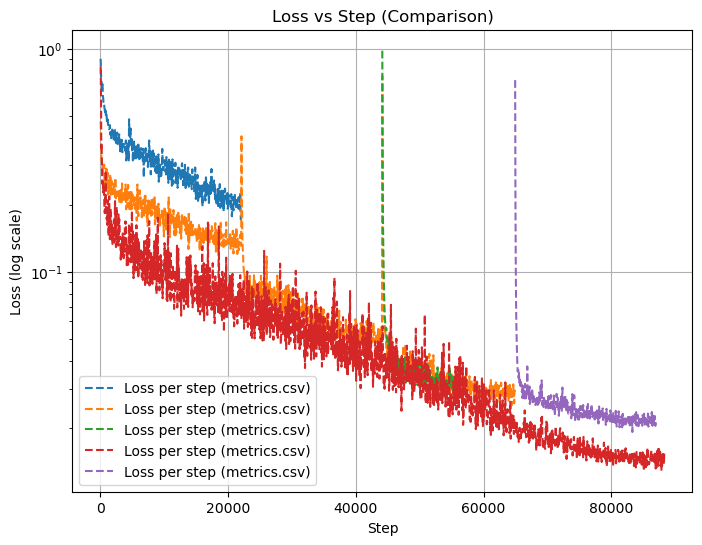

In [22]:
# Load the second uploaded CSV file to check its contents
file_path_2 = '/ibex/ai/home/liux0t/AI4S-cupv2/lightning_logs/version_61_11/metrics.csv'
metrics_df_2 = pd.read_csv(file_path_2)

file_path_3 = '/ibex/ai/home/liux0t/AI4S-cupv2/logs/lightning_logs/version_7/metrics.csv'
metrics_df_3 = pd.read_csv(file_path_3)

file_path_4 = '/ibex/ai/home/liux0t/AI4S-cupv2/logs/lightning_logs/version_8/metrics.csv'
metrics_df_4 = pd.read_csv(file_path_4)

file_path_5 = '/ibex/ai/home/liux0t/AI4S-cupv2/logs/lightning_logs/version_15/metrics.csv' #15 for the first time MgNO13
metrics_df_5 = pd.read_csv(file_path_5)

file_path_6 = '/ibex/ai/home/liux0t/AI4S-cupv2/logs/lightning_logs/version_26/metrics.csv'
metrics_df_6 = pd.read_csv(file_path_6)

file_path_7 = '/ibex/ai/home/liux0t/AI4S-cupv2/logs/lightning_logs/version_17/metrics.csv'  
metrics_df_7 = pd.read_csv(file_path_7)

file_path_8 = '/ibex/ai/home/liux0t/AI4S-cupv2/logs/lightning_logs/version_24/metrics.csv'
metrics_df_8 = pd.read_csv(file_path_8)


# Extract the step and loss_step columns, filtering out NaN values from the second metrics file
loss_data_2 = metrics_df_2[['step', 'loss_step']].dropna()
loss_data_3 = metrics_df_3[['step', 'loss_step']].dropna()
loss_data_4 = metrics_df_4[['step', 'loss_step']].dropna()
loss_data_5 = metrics_df_5[['step', 'loss_step']].dropna()
loss_data_6 = metrics_df_6[['step', 'loss_step']].dropna()
loss_data_7 = metrics_df_7[['step', 'loss_step']].dropna()
loss_data_8 = metrics_df_8[['step', 'loss_step']].dropna()

loss_data_4['step'] += loss_data_3['step'].max()
loss_data_5['step'] += loss_data_4['step'].max()
loss_data_6['step'] += loss_data_4['step'].max()
loss_data_8['step'] += loss_data_5['step'].max()

combined_loss_data_all = pd.concat([loss_data_3, loss_data_4, loss_data_5])




# Plotting both loss records in the same plot with y-axis in log scale
plt.figure(figsize=(8, 6))
# plt.plot(loss_data['step'], loss_data['loss_step'], label='Loss per step (metrics5.csv)')
plt.plot(loss_data_2['step'], loss_data_2['loss_step'], label='Loss per step (metrics.csv)', linestyle='--')
plt.plot(combined_loss_data_all['step'], combined_loss_data_all ['loss_step'], label='Loss per step (metrics.csv)', linestyle='--')
# plt.plot(loss_data_5['step'], loss_data_5['loss_step'], label='Loss per step (metrics.csv)', linestyle='--')
plt.plot(loss_data_6['step'], loss_data_6['loss_step'], label='Loss per step (metrics.csv)', linestyle='--') # retrain from version 16
plt.plot(loss_data_7['step'], loss_data_7['loss_step'], label='Loss per step (metrics.csv)', linestyle='--')
plt.plot(loss_data_8['step'], loss_data_8['loss_step'], label='Loss per step (metrics.csv)', linestyle='--')
plt.yscale('log')
plt.xlabel('Step')
plt.ylabel('Loss (log scale)')
plt.title('Loss vs Step (Comparison)')
plt.legend()
plt.grid(True)

# Display the plot
plt.show()